In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:/Loudot_2024/Loudot/Training/MASG/Immersion_MASG/Master_2_MASG/Cours/IA_DataScience_4_SP/DS_IA_Disease_Ecology_Course/INOHA-DataScience-M2/epidemioes_RDC.csv")
df

,RDC,Cas_Suspects,Cas_Confirmes
0,RDC,112,52
1,RDC,189,85
2,RDC,102,50
3,RDC,24,18
4,RDC,116,50
...,...,...,...
95,RDC,166,74
96,RDC,24,19
97,RDC,54,29
98,RDC,74,41


In [4]:
df.shape

(100, 3)

In [5]:
df.columns

Index(['RDC', 'Cas_Suspects', 'Cas_Confirmes'], dtype='object')

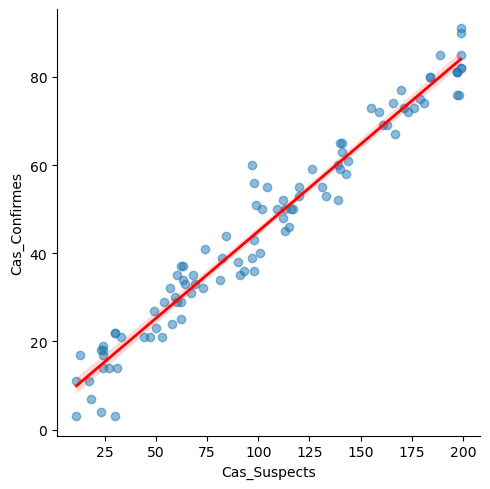

In [6]:
sns.lmplot(x='Cas_Suspects', y='Cas_Confirmes', data =df,
           scatter_kws={'alpha':0.5},
           line_kws={'color':'red', 'linewidth':2})

In [7]:
from sklearn.model_selection import train_test_split

x=df['Cas_Suspects']
y=df['Cas_Confirmes']

In [24]:
x_train,x_test,y_train,y_test= train_test_split(x, y, test_size=0.2, random_state=5)

In [25]:
x_train

94     50
56     62
22     47
39     60
24    197
     ... 
73     63
16    140
61    197
78     53
99     98
Name: Cas_Suspects, Length: 80, dtype: int64

In [26]:
x_train = np.array(x_train).reshape(-1,1)
x_test = np.array(x_test).reshape(-1,1)

In [27]:
from sklearn.linear_model import LinearRegression

model_RLS = LinearRegression()

model_RLS.fit(x_train,y_train)

LinearRegression()

In [28]:
B0 = model_RLS.intercept_
B0

6.1161440587527025

In [29]:
B1= model_RLS.coef_
B1

array([0.38828623])

In [30]:
y_pred = model_RLS.predict(x_test)
y_pred

array([41.0619047 , 75.6193791 , 17.76473094, 18.15301717, 50.76906043,
       60.08792993, 38.73218732, 43.7799083 , 67.85365452, 83.38510369,
       27.08360044, 77.56081025, 60.86450239, 51.54563289, 52.71049157,
       15.43501356, 34.4610388 , 60.08792993, 55.04020895, 49.99248797])

In [31]:
y_test

66    38
32    75
46     3
28    14
74    46
23    60
10    44
20    60
17    72
35    90
97    29
37    80
70    65
40    50
60    53
34    17
42    32
57    52
12    59
69    50
Name: Cas_Confirmes, dtype: int64

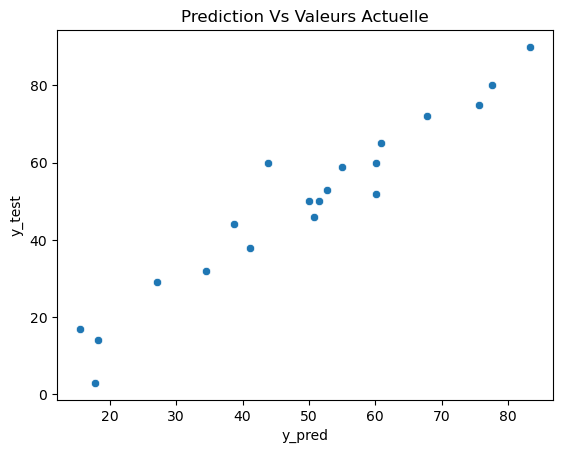

In [32]:
sns.scatterplot(x=y_pred.flatten(), y=y_test)
plt.xlabel('y_pred')
plt.ylabel('y_test')
plt.title('Prediction Vs Valeurs Actuelle')
plt.show()

In [34]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math


print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred) )

MSE 36.917176380355485
MAE 4.305632745837599
RMSE 6.07595065651092
R2 0.9237008016361447


MES AJOUTS

In [35]:
y_pred_series = pd.Series(y_pred.flatten(), index=y_test.index)
results_df = pd.DataFrame({'Exam Score': y_test, 'Valeur Predicte': y_pred_series})

results_df['Diff ou Risidual'] = np.abs(results_df['Exam Score'] - results_df['Valeur Predicte'])
display(results_df.head(15))

,Exam Score,Valeur Predicte,Diff ou Risidual
66,38,41.061905,3.061905
32,75,75.619379,0.619379
46,3,17.764731,14.764731
28,14,18.153017,4.153017
74,46,50.769060,4.769060
23,60,60.087930,0.087930
10,44,38.732187,5.267813
20,60,43.779908,16.220092
17,72,67.853655,4.146345
35,90,83.385104,6.614896


In [36]:
# Calcul Manuel de MAE

y_test_np = y_test.to_numpy()  #ceci est notre y_test

y_pred_np = y_pred.flatten()  #Ceci est les Y Predicte

MAE = np.mean(np.abs(y_test_np - y_pred_np))

print(f"MAE Calculer est : {MAE}")

MAE Calculer est : 4.305632745837599


In [37]:
# Calcul de MSE
MSE= np.mean((y_test_np - y_pred_np)**2)

print(f"MSE Calculer est: {MSE}")

MSE Calculer est: 36.917176380355485


In [38]:
import math
from sklearn.metrics import mean_squared_error

rmse = math.sqrt(mean_squared_error(y_test, y_pred))
print(f"RSE (RMSE): {rmse}")

RSE (RMSE): 6.07595065651092


In [39]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

R2 Score: 0.9237008016361447


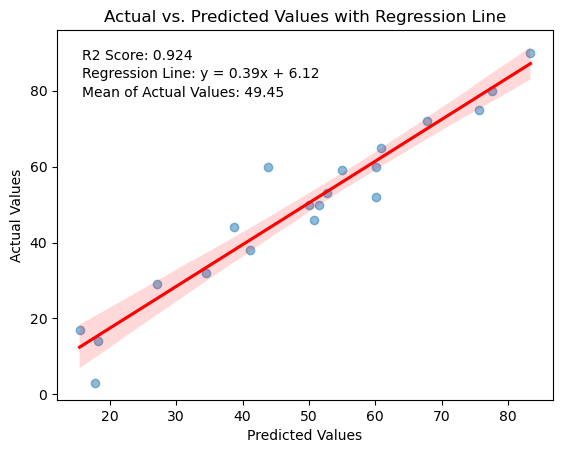

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(x=y_pred.flatten(), y=y_test, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs. Predicted Values with Regression Line')

plt.text(0.05, 0.95, f'R2 Score: {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')


plt.text(0.05, 0.90, f'Regression Line: y = {B1[0]:.2f}x + {B0:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

mean_y_test = y_test.mean()
plt.text(0.05, 0.85, f'Mean of Actual Values: {mean_y_test:.2f}', transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

plt.show()

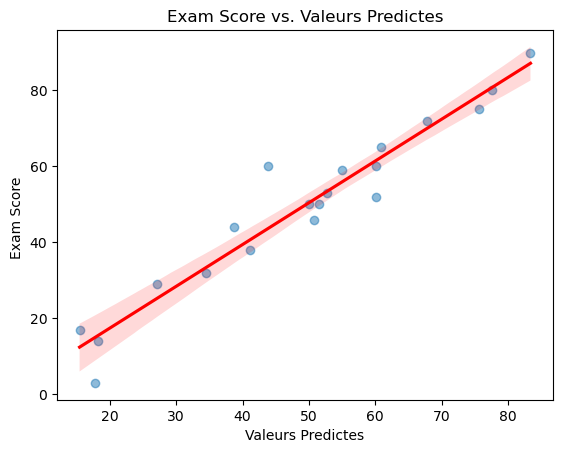

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(x=y_pred.flatten(), y=y_test, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Valeurs Predictes')
plt.ylabel('Exam Score ')
plt.title('Exam Score vs. Valeurs Predictes')
plt.show()

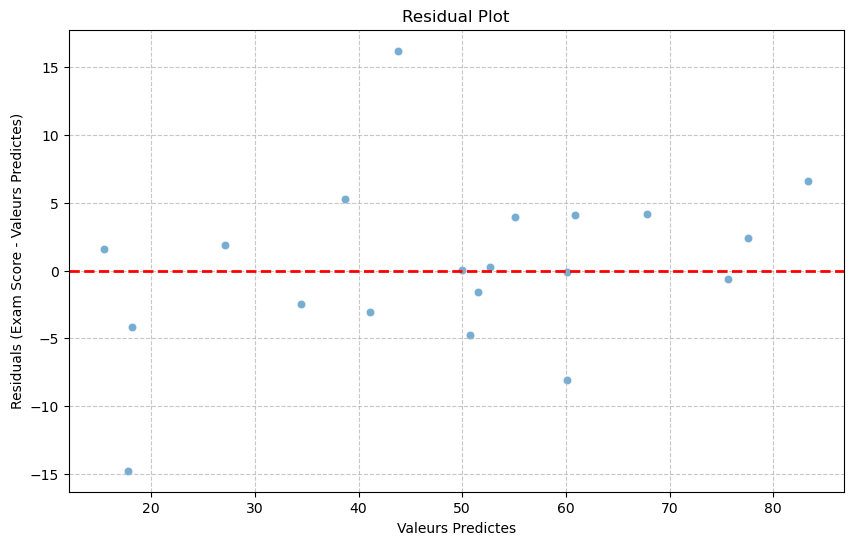

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# La Difference ou residuals
residuals = y_test - y_pred.flatten()

# Creation de Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred.flatten(), y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Valeurs Predictes')
plt.ylabel('Residuals (Exam Score - Valeurs Predictes)')
plt.title('Residual Plot')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [43]:
my_data = np.array([[78],[89],[98]])

prediction  = model_RLS.predict(my_data)
print(prediction)

[36.40246994 40.67361847 44.16819453]


REGRESSION LINEAIRE MULTIPLE